# 53 — Masked image modeling and a tiny MAE

Masked image modeling removes part of an image and asks a model to predict the missing content. A **masked autoencoder (MAE)** performs this task with image patches:

1. divide an image into non-overlapping patches;
2. hide a large random subset;
3. encode only the visible patches;
4. insert learned mask tokens for missing positions;
5. decode the complete sequence and reconstruct masked pixels.

This notebook will implement the essential mechanics, train tiny MAEs with 50% and 75% masking on CIFAR-10, visualize reconstruction, and evaluate their frozen representations with linear probes.

The purpose is conceptual. CIFAR-10 images are only $32\times32$, while influential MAE results use larger images, larger models, and much longer training.

In [1]:
from copy import deepcopy
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10

from cs231n_practice.self_supervised import extract_features, freeze_encoder, train_linear_probe

SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

print(f"Using {DEVICE}")

Using mps


## 1. Data roles

We retain the same educational protocol as the [SimCLR notebook](./52_simclr_cifar10.ipynb):

- 6,000 images without class labels for self-supervised pretraining;
- 1,000 disjoint labeled images for linear probes;
- 2,000 held-out test images for evaluation.

Pixel reconstruction uses values in `[0, 1]`, so we do not apply CIFAR channel normalization to the MAE inputs or targets.

In [2]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)

all_train_images = torch.from_numpy(train_dataset.data).permute(0, 3, 1, 2).float() / 255.0
all_train_labels = torch.tensor(train_dataset.targets)
all_test_images = torch.from_numpy(test_dataset.data).permute(0, 3, 1, 2).float() / 255.0
all_test_labels = torch.tensor(test_dataset.targets)

generator = torch.Generator().manual_seed(SEED)
train_order = torch.randperm(len(all_train_images), generator=generator)
test_order = torch.randperm(len(all_test_images), generator=generator)

pretrain_images = all_train_images[train_order[:6000]]
probe_images = all_train_images[train_order[6000:7000]]
probe_labels = all_train_labels[train_order[6000:7000]]
evaluation_images = all_test_images[test_order[:2000]]
evaluation_labels = all_test_labels[test_order[:2000]]

assert pretrain_images.shape == (6000, 3, 32, 32)

## 2. Convert images into patch sequences

With patch size $P$, an image shaped `(N, C, H, W)` becomes

$$
\left(N,\frac{H}{P}\frac{W}{P},CP^2\right).
$$

For a $32\times32$ RGB image and $P=8$:

- the grid is $4\times4$;
- there are 16 patch tokens;
- each flattened patch contains $3\cdot8\cdot8=192$ pixel values.

The patch order is row-major: all columns of the first patch row, followed by all columns of the next row.

### Exercise 1 — Patchify

Use `unfold` to expose non-overlapping height and width windows, then permute and reshape them into row-major patch vectors.

In [7]:
sample_images = pretrain_images[:4]
(
    sample_images.shape,
    sample_images.unfold(2, 8, 8).shape,
    sample_images.unfold(2, 8, 8).unfold(3, 8, 8).shape
)

(torch.Size([4, 3, 32, 32]),
 torch.Size([4, 3, 4, 32, 8]),
 torch.Size([4, 3, 4, 4, 8, 8]))

In [6]:
def patchify(images, patch_size):
    # Convert (N, C, H, W) images to (N, number_of_patches, patch_dim).
    if images.ndim != 4:
        raise ValueError("images must have shape (N, C, H, W)")
    n, channels, height, width = images.shape
    if height % patch_size != 0 or width % patch_size != 0:
        raise ValueError("height and width must be divisible by patch_size")

    # expose (patch_size, patch_size) windows with non-overlapping steps.
    windows = images.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    # reorder to (N, grid_h, grid_w, C, P, P) and flatten patch contents.
    patches = windows.permute(0, 2, 3, 1, 4, 5).reshape(n, -1, channels * patch_size * patch_size)
    return patches


sample_images = pretrain_images[:4]
sample_patches = patchify(sample_images, patch_size=8)
assert sample_patches.shape == (4, 16, 192)

# The first patch must equal the top-left 8x8 image region.
expected_first = sample_images[0, :, :8, :8].reshape(-1)
torch.testing.assert_close(sample_patches[0, 0], expected_first)

### Exercise 2 — Unpatchify

Reconstruction produces patch vectors, so we also need the inverse operation. Restore the channel and within-patch axes, move them next to their grid axes, and reshape the result into an image.

`unpatchify(patchify(images))` should be an exact round trip.

In [27]:
sample = torch.arange(128).reshape(2, 4, 2, 8)
(
    sample.shape,
    sample.unfold(2, 2, 2).shape,
    sample.reshape(2 * 4, 2 * 8).shape,
    sample.permute(0, 2, 1, 3).reshape(2 * 2, 4 * 8).shape
)

(torch.Size([2, 4, 2, 8]),
 torch.Size([2, 4, 1, 8, 2]),
 torch.Size([8, 16]),
 torch.Size([4, 32]))

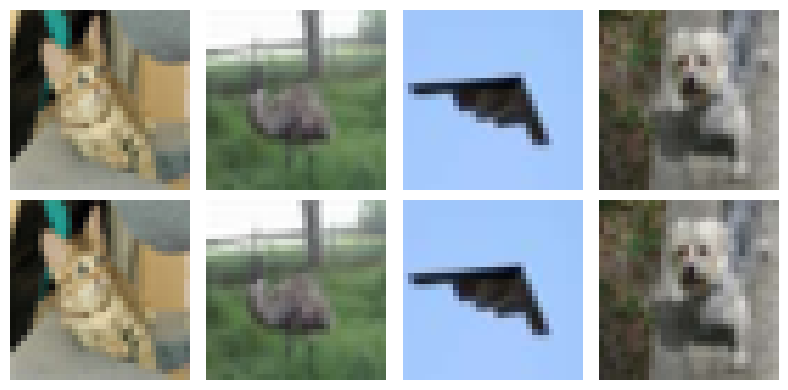

In [10]:
def unpatchify(patches, patch_size, channels, image_height, image_width):
    # Convert (N, number_of_patches, patch_dim) back to (N, C, H, W).
    n, number_of_patches, patch_dim = patches.shape
    grid_height = image_height // patch_size
    grid_width = image_width // patch_size
    if number_of_patches != grid_height * grid_width:
        raise ValueError("patch count does not match the image grid")
    if patch_dim != channels * patch_size * patch_size:
        raise ValueError("patch_dim does not match channels * patch_size squared")

    # restore (N, grid_h, grid_w, C, P, P).
    patch_grid = patches.reshape(n, grid_height, grid_width, channels, patch_size, patch_size)
    # reorder to (N, C, grid_h, P, grid_w, P), then merge grid axes.
    images = patch_grid.permute(0, 3, 1, 4, 2, 5).reshape(n, channels, image_height, image_width)
    return images


restored_images = unpatchify(sample_patches, 8, 3, 32, 32)
assert restored_images.shape == sample_images.shape
torch.testing.assert_close(restored_images, sample_images)

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for column in range(4):
    axes[0, column].imshow(sample_images[column].permute(1, 2, 0))
    axes[1, column].imshow(restored_images[column].permute(1, 2, 0))
    axes[0, column].axis("off")
    axes[1, column].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("round trip")
plt.tight_layout()
plt.show()

## 3. Random masking and restoration indices

For each image, assign one random noise value to every patch and sort the patches by that noise. The first $K$ shuffled indices are kept:

```text
original positions:  0  1  2  3
random shuffle:      2  0  3  1
keep first K=2:      2  0
```

`ids_keep` selects visible patches in shuffled order. `ids_restore = argsort(ids_shuffle)` tells us how to undo the shuffle later. The binary mask is `0` for visible positions and `1` for masked positions, returned in original spatial order.

### Exercise 3 — Mask patches

Complete the masking function. Use `torch.gather` to select visible patches independently for every batch row.

In [32]:
noise = torch.rand(4)
ids_shuffle = torch.argsort(noise, dim=0)
ids_restore = torch.argsort(ids_shuffle, dim=0)
(
    noise,
    ids_shuffle,
    ids_restore,
)


(tensor([0.2512, 0.0572, 0.3289, 0.1095]),
 tensor([1, 3, 0, 2]),
 tensor([2, 0, 3, 1]))

In [ ]:
def random_mask_patches(patches, mask_ratio):
    # Return visible patches, the original-order mask, kept indices, and restoration indices.
    if patches.ndim != 3:
        raise ValueError("patches must have shape (N, L, patch_dim)")
    if not 0.0 < mask_ratio < 1.0:
        raise ValueError("mask_ratio must be between 0 and 1")

    n, number_of_patches, patch_dim = patches.shape
    number_to_keep = max(1, int(number_of_patches * (1.0 - mask_ratio)))
    noise = torch.rand(n, number_of_patches, device=patches.device)

    # sort noise to obtain the shuffle and inverse-restoration indices.
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    # take the first number_to_keep shuffled indices and gather visible patches.
    ids_keep = ids_shuffle[:, :number_to_keep]
    visible_patches = patches.gather(1, ids_keep.unsqueeze(-1).expand(-1, -1, patch_dim))

    # Construct a mask in shuffled order, then restore original patch order.
    mask = torch.ones(n, number_of_patches, device=patches.device)
    mask[:, :number_to_keep] = 0
    # gather mask with ids_restore.
    mask = mask.gather(1, ids_restore)
    return visible_patches, mask, ids_keep, ids_restore


torch.manual_seed(SEED)
visible_patches, sample_mask, ids_keep, ids_restore = random_mask_patches(
    sample_patches,
    mask_ratio=0.75,
)
assert visible_patches.shape == (4, 4, 192)
assert sample_mask.shape == (4, 16)
assert torch.all(sample_mask.sum(dim=1) == 12)
torch.testing.assert_close(
    visible_patches,
    sample_patches.gather(1, ids_keep.unsqueeze(-1).expand(-1, -1, 192)),
)

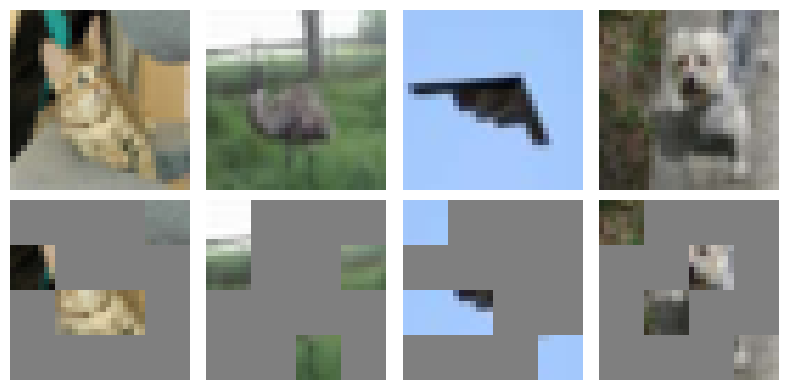

In [35]:
def patches_with_mask_color(patches, mask, fill_value=0.5):
    displayed = patches.clone()
    displayed[mask.bool()] = fill_value
    return displayed


masked_sample_patches = patches_with_mask_color(sample_patches, sample_mask)
masked_sample_images = unpatchify(masked_sample_patches, 8, 3, 32, 32)

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for column in range(4):
    axes[0, column].imshow(sample_images[column].permute(1, 2, 0))
    axes[1, column].imshow(masked_sample_images[column].permute(1, 2, 0))
    axes[0, column].axis("off")
    axes[1, column].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("75% masked")
plt.tight_layout()
plt.show()

## 4. Why the encoder sees only visible patches

An ordinary denoising autoencoder might pass every position—including placeholders for missing content—through its encoder. MAE instead removes masked patches before the encoder:

```text
16 original patches
      ↓ 75% masking
4 visible tokens → expensive encoder
      ↓
4 encoded tokens + 12 learned mask tokens
      ↓
16-token lightweight decoder → 16 predicted patches
```

This has two benefits:

- the encoder cannot inspect mask placeholders as shortcuts;
- high masking greatly reduces the encoder sequence length and therefore its attention cost.

The decoder still needs a token at every original position. We append learned mask tokens in shuffled order and use `ids_restore` to return the complete sequence to spatial order.

### Exercise 4 — Restore the full token sequence

`visible_tokens` follow the kept part of `ids_shuffle`. Append enough copies of `mask_token`, then gather with `ids_restore`.

In [37]:
def restore_mask_tokens(visible_tokens, ids_restore, mask_token):
    n, number_visible, feature_dim = visible_tokens.shape
    number_of_patches = ids_restore.shape[1]
    number_masked = number_of_patches - number_visible

    # expand the learned (1, 1, D) token for all missing positions.
    mask_tokens = mask_token.expand(n, number_masked, feature_dim)
    # concatenate visible and mask tokens in shuffled order.
    shuffled_tokens = torch.cat([visible_tokens, mask_tokens], dim=1)
    # gather with ids_restore expanded across the feature dimension.
    restored_tokens = shuffled_tokens.gather(1, ids_restore.unsqueeze(-1).expand(-1, -1, feature_dim))
    return restored_tokens


toy_visible = torch.tensor([[[20.0], [0.0]]])
toy_restore = torch.tensor([[1, 3, 0, 2]])
toy_mask_token = torch.tensor([[[-1.0]]])
toy_restored = restore_mask_tokens(toy_visible, toy_restore, toy_mask_token)
torch.testing.assert_close(
    toy_restored,
    torch.tensor([[[0.0], [-1.0], [20.0], [-1.0]]]),
)

## 5. A tiny masked autoencoder

The model uses separate encoder and decoder widths:

- a linear layer embeds raw pixel patches;
- positional embeddings retain patch location after random selection;
- a Transformer encoder processes visible tokens only;
- a projection changes encoder width to decoder width;
- mask tokens and restoration indices rebuild the full sequence;
- a small Transformer decoder predicts raw pixel vectors.

Unlike a classification token, the downstream representation here is the mean of all encoder tokens when `encode_all` receives an unmasked image.

### Exercise 5 — Connect the MAE stages

Complete the marked lines in `forward`. Track the shapes: `(N, L, patch_dim)`, `(N, K, encoder_dim)`, and finally `(N, L, patch_dim)`.

In [41]:
class TinyMaskedAutoencoder(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=8,
        encoder_dim=48,
        decoder_dim=32,
        num_heads=4,
    ):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.channels = 3
        self.patch_dim = self.channels * patch_size * patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.feature_dim = encoder_dim

        self.patch_embedding = nn.Linear(self.patch_dim, encoder_dim)
        self.encoder_position = nn.Parameter(
            torch.zeros(1, self.num_patches, encoder_dim)
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=encoder_dim,
            nhead=num_heads,
            dim_feedforward=2 * encoder_dim,
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2,
            enable_nested_tensor=False,
        )

        self.decoder_projection = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.decoder_position = nn.Parameter(
            torch.zeros(1, self.num_patches, decoder_dim)
        )
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim,
            nhead=num_heads,
            dim_feedforward=2 * decoder_dim,
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerEncoder(
            decoder_layer,
            num_layers=1,
            enable_nested_tensor=False,
        )
        self.pixel_prediction = nn.Linear(decoder_dim, self.patch_dim)

        nn.init.normal_(self.encoder_position, std=0.02)
        nn.init.normal_(self.decoder_position, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

    def forward(self, images, mask_ratio=0.75):
        target_patches = patchify(images, self.patch_size)
        visible_patches, mask, ids_keep, ids_restore = random_mask_patches(
            target_patches,
            mask_ratio,
        )

        # embed visible pixel patches.
        visible_tokens = self.patch_embedding(visible_patches)
        all_encoder_positions = self.encoder_position.expand(len(images), -1, -1)
        visible_positions = all_encoder_positions.gather(
            1,
            ids_keep.unsqueeze(-1).expand(-1, -1, self.feature_dim),
        )
        # encode visible tokens after adding their positions.
        encoded_visible = self.encoder(visible_tokens + visible_positions)

        decoder_visible = self.decoder_projection(encoded_visible)
        # rebuild the complete original-order sequence with mask tokens.
        complete_tokens = restore_mask_tokens(decoder_visible, ids_restore, self.mask_token)
        decoded = self.decoder(complete_tokens + self.decoder_position)
        predicted_patches = self.pixel_prediction(decoded)
        return predicted_patches, target_patches, mask

    def encode_all(self, images):
        patches = patchify(images, self.patch_size)
        tokens = self.patch_embedding(patches) + self.encoder_position
        encoded = self.encoder(tokens)
        return encoded.mean(dim=1)


torch.manual_seed(SEED + 1)
sample_mae = TinyMaskedAutoencoder()
sample_predictions, sample_targets, model_mask = sample_mae(sample_images, 0.75)
assert sample_predictions.shape == (4, 16, 192)
assert sample_targets.shape == sample_predictions.shape
assert model_mask.shape == (4, 16)
assert sample_mae.encode_all(sample_images).shape == (4, 48)

## 6. Loss on masked patches only

The decoder predicts every position, but visible patches already appear in the input. Computing loss mainly or equally on visible patches can let the model spend capacity copying known pixels. MAE therefore averages squared error only over masked positions:

$$
L = \frac{\sum_{n,l,d} M_{nl}(\hat{X}_{nld}-X_{nld})^2}
{D\sum_{n,l}M_{nl}},
$$

where $M_{nl}=1$ for a masked patch and $D$ is the number of pixel values per patch.

### Exercise 6 — Masked reconstruction loss

Calculate elementwise squared error, multiply by `mask.unsqueeze(-1)`, and divide by the number of masked pixel values.

In [43]:
def masked_reconstruction_loss(predictions, targets, mask):
    if predictions.shape != targets.shape:
        raise ValueError("predictions and targets must have the same shape")
    if mask.shape != predictions.shape[:2]:
        raise ValueError("mask must have shape (N, number_of_patches)")

    # calculate squared error and keep only mask == 1 positions.
    squared_error = (predictions - targets) ** 2
    masked_error = squared_error * mask.unsqueeze(-1)
    # divide by masked patch count times patch_dim.
    denominator = mask.sum() * predictions.shape[-1]
    return masked_error.sum() / denominator


toy_predictions = torch.tensor([[[1.0, 2.0], [5.0, 8.0]]])
toy_targets = torch.tensor([[[1.0, 0.0], [2.0, 4.0]]])
toy_mask = torch.tensor([[0.0, 1.0]])
toy_loss = masked_reconstruction_loss(toy_predictions, toy_targets, toy_mask)
# Only the second patch contributes: ((5-2)^2 + (8-4)^2) / 2 = 12.5.
torch.testing.assert_close(toy_loss, torch.tensor(12.5))

## 7. Compare 50% and 75% masking

A lower ratio leaves more evidence and makes reconstruction easier. A higher ratio makes the task harder but shortens the expensive encoder sequence and forces greater use of context.

Both models below begin from the same weights and use the same images, optimizer, and epoch budget. Only the mask ratio changes. Reconstruction loss may favor the easier setting; downstream representation quality is a separate question.

In [47]:
def pretrain_mae(
    model,
    images,
    mask_ratio,
    epochs=20,
    batch_size=128,
    learning_rate=2e-3,
):
    loader = DataLoader(
        TensorDataset(images),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []
    model.to(DEVICE)

    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        example_count = 0
        start_time = time.perf_counter()
        for (image_batch,) in loader:
            image_batch = image_batch.to(DEVICE)
            predictions, targets, mask = model(image_batch, mask_ratio)
            loss = masked_reconstruction_loss(predictions, targets, mask)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * len(image_batch)
            example_count += len(image_batch)

        history.append(loss_sum / example_count)
        elapsed = time.perf_counter() - start_time
        print(
            f"mask={mask_ratio:.2f}, epoch {epoch + 1:2d}: "
            f"loss={history[-1]:.4f}, time={elapsed:.1f}s"
        )
    return history


torch.manual_seed(SEED + 2)
initial_model = TinyMaskedAutoencoder()
initial_state = deepcopy(initial_model.state_dict())
mae_models = {}
mae_histories = {}

for mask_ratio in (0.50, 0.75):
    model = TinyMaskedAutoencoder()
    model.load_state_dict(initial_state)
    history = pretrain_mae(model, pretrain_images, mask_ratio)
    mae_models[mask_ratio] = model
    mae_histories[mask_ratio] = history

mask=0.50, epoch  1: loss=0.1115, time=0.8s
mask=0.50, epoch  2: loss=0.0516, time=0.6s
mask=0.50, epoch  3: loss=0.0497, time=0.4s
mask=0.50, epoch  4: loss=0.0496, time=0.4s
mask=0.50, epoch  5: loss=0.0476, time=0.4s
mask=0.50, epoch  6: loss=0.0454, time=0.4s
mask=0.50, epoch  7: loss=0.0440, time=0.4s
mask=0.50, epoch  8: loss=0.0416, time=0.4s
mask=0.50, epoch  9: loss=0.0401, time=0.4s
mask=0.50, epoch 10: loss=0.0390, time=0.4s
mask=0.50, epoch 11: loss=0.0391, time=0.4s
mask=0.50, epoch 12: loss=0.0386, time=0.4s
mask=0.50, epoch 13: loss=0.0370, time=0.4s
mask=0.50, epoch 14: loss=0.0367, time=0.4s
mask=0.50, epoch 15: loss=0.0365, time=0.4s
mask=0.50, epoch 16: loss=0.0361, time=0.4s
mask=0.50, epoch 17: loss=0.0359, time=0.4s
mask=0.50, epoch 18: loss=0.0355, time=0.4s
mask=0.50, epoch 19: loss=0.0352, time=0.4s
mask=0.50, epoch 20: loss=0.0349, time=0.4s
mask=0.75, epoch  1: loss=0.1065, time=0.4s
mask=0.75, epoch  2: loss=0.0535, time=0.4s
mask=0.75, epoch  3: loss=0.0522

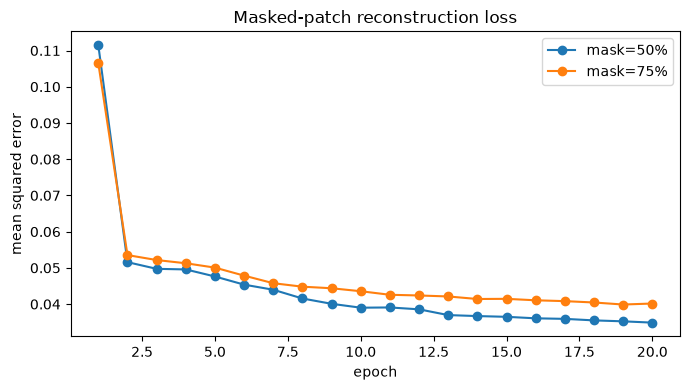

In [48]:
fig, axis = plt.subplots(figsize=(7, 4))
for mask_ratio, history in mae_histories.items():
    axis.plot(np.arange(1, len(history) + 1), history, marker="o", label=f"mask={mask_ratio:.0%}")
axis.set(title="Masked-patch reconstruction loss", xlabel="epoch", ylabel="mean squared error")
axis.legend()
plt.tight_layout()
plt.show()

### Exercise 7 — Interpret masking difficulty

1. Which masking ratio obtains lower reconstruction loss?
2. Why is that result expected?
3. Why does lower reconstruction loss not automatically imply a better representation?

**Your answers:**

1. The 50% masking model obtained a slightly lower final reconstruction loss: 0.0349 versus 0.0402.
2. With 50% masking, the encoder sees eight of the sixteen patches instead of only four. The decoder therefore receives more information about the image and has an easier reconstruction problem.
3. Reconstruction loss measures pixel accuracy, not semantic understanding. A model may predict common colors, textures, and local patterns accurately without learning features that distinguish object classes. Representation quality should therefore be evaluated separately, for example with a frozen linear probe.

## 8. Visualize masked inputs and reconstructions

We show four rows for each ratio:

- the original image;
- the masked input, with gray missing patches;
- the decoder prediction at every position;
- a combined image that preserves original visible patches and inserts predictions only where patches were masked.

The combined row is usually easiest to interpret because visible regions are not replaced by unconstrained predictions.

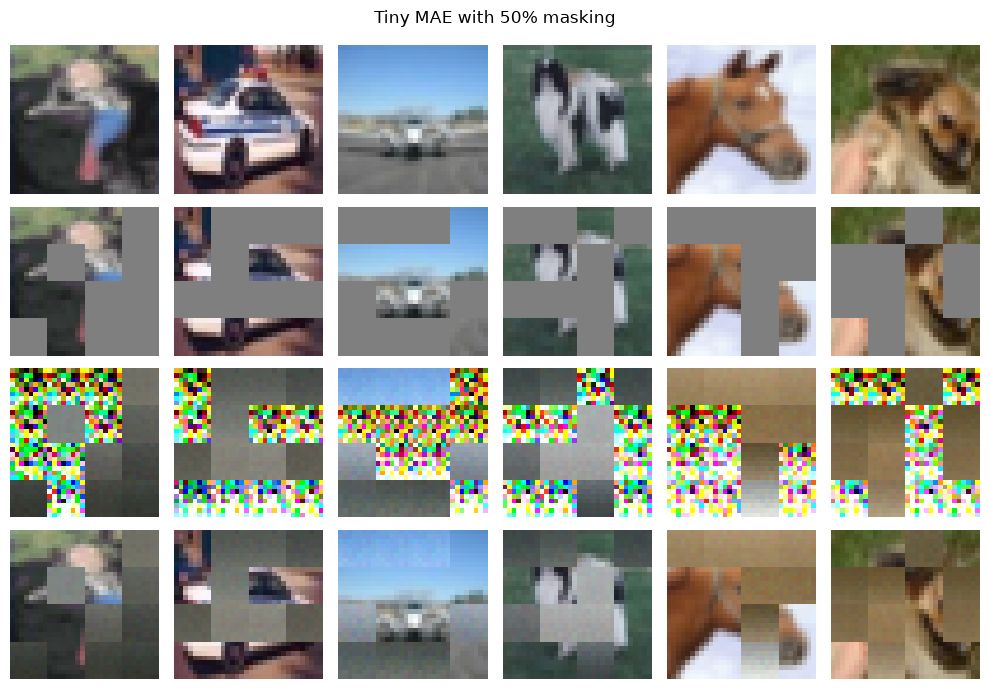

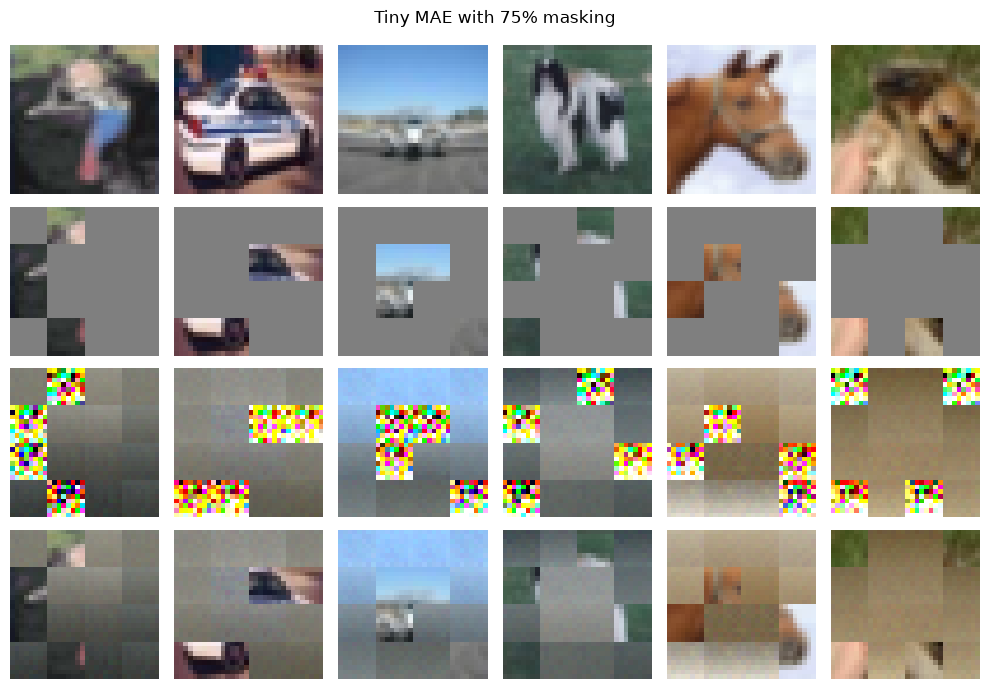

In [49]:
@torch.no_grad()
def reconstruction_examples(model, images, mask_ratio):
    model.eval()
    predictions, targets, mask = model(images.to(DEVICE), mask_ratio)
    predictions = predictions.cpu()
    targets = targets.cpu()
    mask = mask.cpu()
    masked_patches = patches_with_mask_color(targets, mask)
    combined_patches = torch.where(mask.unsqueeze(-1).bool(), predictions, targets)
    kwargs = dict(patch_size=8, channels=3, image_height=32, image_width=32)
    return (
        unpatchify(masked_patches, **kwargs).clamp(0, 1),
        unpatchify(predictions, **kwargs).clamp(0, 1),
        unpatchify(combined_patches, **kwargs).clamp(0, 1),
    )


visualization_images = evaluation_images[:6]
for mask_ratio, model in mae_models.items():
    torch.manual_seed(SEED + 20)
    masked_images, predicted_images, combined_images = reconstruction_examples(
        model,
        visualization_images,
        mask_ratio,
    )
    rows = (visualization_images, masked_images, predicted_images, combined_images)
    row_names = ("original", "masked", "prediction", "combined")
    fig, axes = plt.subplots(4, 6, figsize=(10, 7))
    for row, (batch, name) in enumerate(zip(rows, row_names)):
        for column in range(6):
            axes[row, column].imshow(batch[column].permute(1, 2, 0))
            axes[row, column].axis("off")
        axes[row, 0].set_ylabel(name)
    plt.suptitle(f"Tiny MAE with {mask_ratio:.0%} masking")
    plt.tight_layout()
    plt.show()

## 9. Frozen representation evaluation

Reconstruction quality and representation quality are related only indirectly. We therefore compare frozen encoders using the same labeled subset and linear-probe procedure:

- the initial random MAE encoder;
- the encoder pretrained with 50% masking;
- the encoder pretrained with 75% masking.

`MAEEncoderView` exposes `encode_all` as an ordinary module forward pass. No decoder parameters are used during feature extraction.

In [50]:
class MAEEncoderView(nn.Module):
    def __init__(self, mae):
        super().__init__()
        self.mae = mae

    def forward(self, images):
        return self.mae.encode_all(images)


random_mae = TinyMaskedAutoencoder()
random_mae.load_state_dict(initial_state)
evaluation_encoders = {
    "random": MAEEncoderView(random_mae),
    "MAE 50%": MAEEncoderView(mae_models[0.50]),
    "MAE 75%": MAEEncoderView(mae_models[0.75]),
}
probe_results = {}

for name, encoder in evaluation_encoders.items():
    encoder = freeze_encoder(encoder.to(DEVICE))
    train_features = extract_features(encoder, probe_images)
    test_features = extract_features(encoder, evaluation_images)
    head, history = train_linear_probe(
        train_features,
        probe_labels,
        test_features,
        evaluation_labels,
        num_classes=10,
        epochs=50,
        learning_rate=5e-2,
        device=DEVICE,
        seed=SEED + 30,
    )
    probe_results[name] = {"head": head, "history": history}
    print(
        f"{name:8s}: train={history['train_accuracy'][-1]:.3f}, "
        f"evaluation={history['evaluation_accuracy'][-1]:.3f}"
    )

random  : train=0.273, evaluation=0.211
MAE 50% : train=0.368, evaluation=0.269
MAE 75% : train=0.373, evaluation=0.290


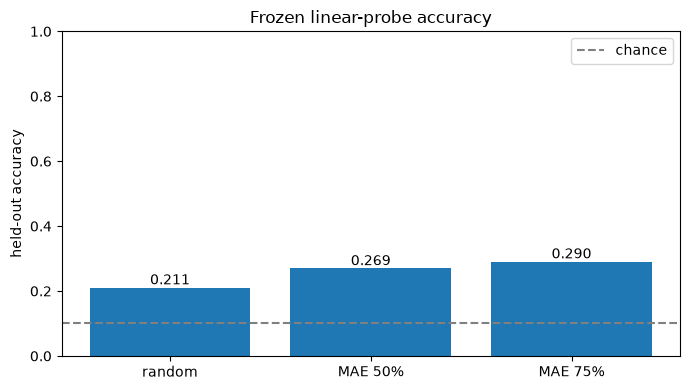

In [51]:
final_accuracies = {
    name: result["history"]["evaluation_accuracy"][-1]
    for name, result in probe_results.items()
}
fig, axis = plt.subplots(figsize=(7, 4))
bars = axis.bar(final_accuracies.keys(), final_accuracies.values())
axis.set(title="Frozen linear-probe accuracy", ylabel="held-out accuracy", ylim=(0, 1))
axis.axhline(0.1, color="gray", linestyle="--", label="chance")
axis.bar_label(bars, fmt="%.3f")
axis.legend()
plt.tight_layout()
plt.show()

### Exercise 8 — Reconstruction versus representation

1. Which encoder produces the strongest frozen linear probe?
2. Does the ratio with lower reconstruction loss also produce the best probe?
3. Why should conclusions from this short run be treated cautiously?

**Your answers:**

1. The encoder pretrained with 75% masking produces the strongest frozen linear probe, reaching 29.0% evaluation accuracy.
2. No. The 50% model has the lower reconstruction loss, but the 75% model produces the better linear-probe accuracy. The harder masking task may encourage the encoder to learn more contextual and semantic features instead of relying mainly on nearby pixel information.
3. The experiment uses a small dataset, a tiny model, one random seed, limited pretraining, and one set of probe hyperparameters. The 2.1-percentage-point difference between the two MAE models may therefore vary across repeated runs.

## 10. MAE compared with DINO

Both methods learn without human class labels, but their targets differ:

- **MAE:** predicts missing image content, usually pixel patches. Its target comes directly from the masked input image.
- **DINO:** a student network matches probability or representation targets produced by a teacher network from another image view. The teacher is updated using an exponential moving average of the student, and gradients do not pass through the teacher target.

MAE emphasizes reconstruction from context. DINO emphasizes agreement between learned representations across views. DINO also needs mechanisms such as teacher–student asymmetry, stop-gradient, centering, and sharpening to avoid collapse without ordinary negative pairs.

We keep DINO conceptual here because implementing and tuning a stable teacher–student system would be a separate substantial project.

## Reflection

1. How does masked image modeling create targets without class labels?
2. Why does patchification preserve a sequence order?
3. What information is carried by `ids_keep` and `ids_restore`?
4. Why does the MAE encoder process only visible patches?
5. Why does the decoder require positional embeddings and mask tokens?
6. Why is reconstruction loss calculated only on masked patches?
7. What tradeoff changes when the mask ratio rises from 50% to 75%?
8. Why can good-looking reconstruction fail to imply a strong representation?
9. Why is a frozen linear probe useful after MAE pretraining?
10. How do the training targets of MAE and DINO differ?

### Answers

1. 
2. 
3. 
4. 
5. 
6. 
7. 
8. 
9. 
10. 